In [1]:
import sys
sys.path.append('..')

import numpy as np
import os
import matplotlib.pyplot as plt

from numcodecs import Blosc
from src.utils import unfold_tensor
from types import SimpleNamespace
import time

In [3]:
npz_path = os.path.join(r"..\data\DEMs", "20240520_1200.npz")
npz = np.load(npz_path)

In [ ]:
AIACube = npz["AIACube"]

In [7]:
compressor = Blosc(cname='zstd', clevel=4, shuffle=2)
AIACube = np.frombuffer(compressor.decode(AIACube), dtype=np.float32).reshape(npz['AIACubeShape'])

In [8]:
print(AIACube.shape)

(6, 4096, 4096)


In [22]:
plt.rcParams["figure.dpi"] = 300
plt.rcParams["text.usetex"] = True
plt.rcParams['font.family'] = 'serif'

In [8]:
def style_ax(ax):
    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor('black')
        spine.set_linewidth(0.8)

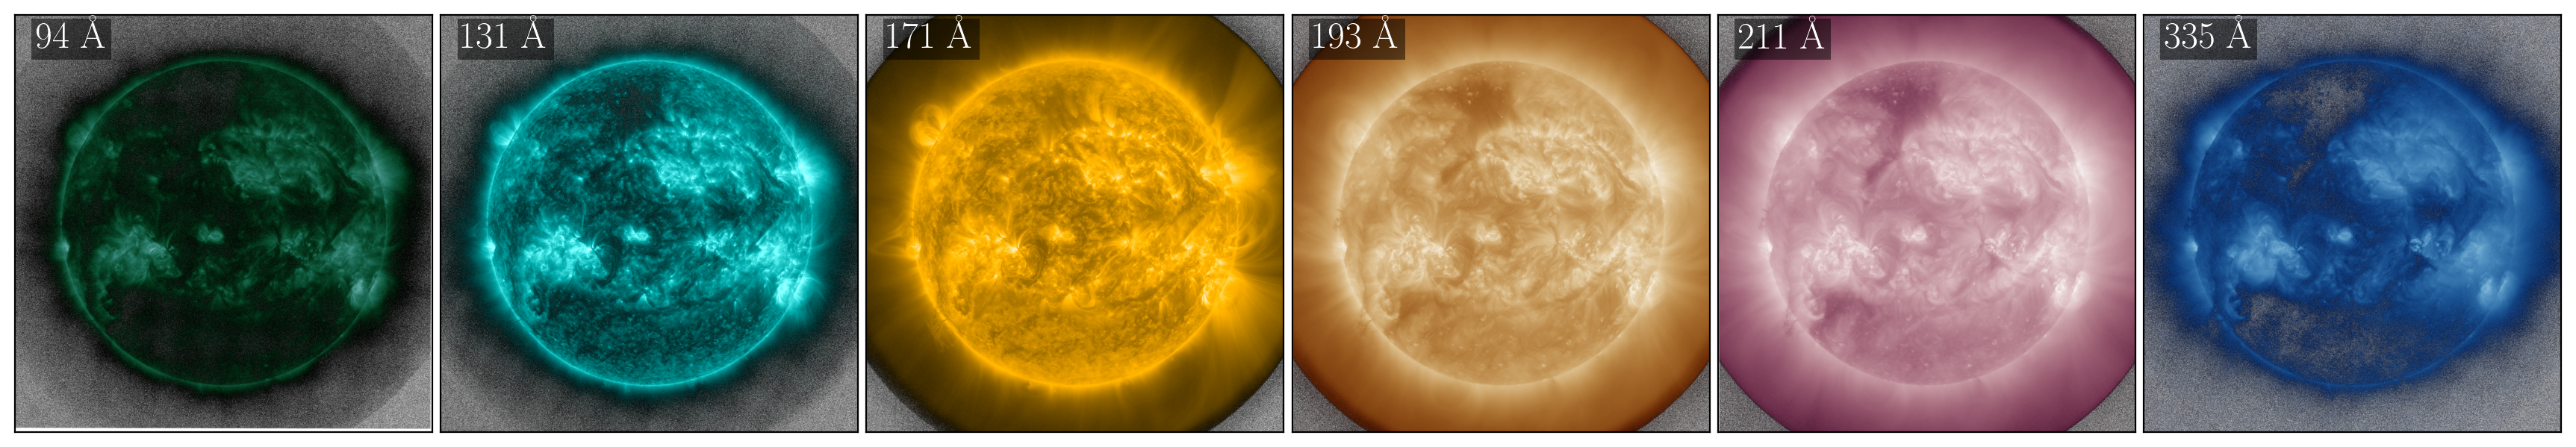

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from sunpy.visualization.colormaps import cm



indices = [0, 1, 2, 3, 4, 5]
labels  = ['94 Å', '131 Å', '171 Å', '193 Å', '211 Å', '335 Å']

cmaps = [
    cm.sdoaia94,
    cm.sdoaia131,
    cm.sdoaia171,
    cm.sdoaia193,
    cm.sdoaia211,
    cm.sdoaia335
]

fig, axes = plt.subplots(1, 6, figsize=(22, 4))

for ax, idx, label, cmap in zip(axes, indices, labels, cmaps):

    data = AIACube[idx]

    ax.imshow(
        data,
        origin='lower',
        cmap=cmap,
        norm=LogNorm(
            vmin=max(1, data.min()),
            vmax=data.max()
        )
    )

    style_ax(ax)

    # Etiqueta dentro de la imagen
    ax.text(
        0.05, 0.92,
        label,
        transform=ax.transAxes,
        fontsize=18,
        color='white',
        weight='bold',
        bbox=dict(
            facecolor='black',
            alpha=0.5,
            edgecolor='none',
            pad=2
        )
    )

plt.subplots_adjust(wspace=0.02)

plt.savefig(
    "aia_img.png",
    dpi=300,
    bbox_inches='tight',
    pad_inches=0.02
)

plt.show()

In [24]:
npz_files = {'npz': np.load(os.path.join(r"..\data\DEMs", "20240520_1200.npz")),
        'npz_8': np.load(os.path.join(r"..\data\DEMs", "20240520_1200_lp_8.npz")),
        'npz_128': np.load(os.path.join(r"..\data\DEMs", "20240520_1200_lp_128.npz")),
        'npz_64': np.load(os.path.join(r"..\data\DEMs", "20240520_1200_lp_64.npz")),

}

In [25]:
compressor = Blosc(cname='zstd', clevel=4, shuffle=2)

# Decodificar todos los DEMs
dems = {
    method: np.frombuffer(
        compressor.decode(npz["DEMCube"]),
        dtype=np.float32
    ).reshape(npz["DEMCubeShape"])
    for method, npz in npz_files.items()
}

In [26]:
dem_8 = dems['npz_8']
dem_128 = dems['npz_128']
dem_64 = dems['npz_64']
dem_256 = dems['npz']

In [27]:
for method, dem in dems.items():
    print(method, dem.shape)

npz (18, 16, 16)
npz_8 (18, 512, 512)
npz_128 (18, 32, 32)
npz_64 (18, 64, 64)


In [28]:
dems = {
    'npz_8': dem_8,
    'npz_128': dem_128,
    'npz_64': dem_64,
    'npz': dem_256
}

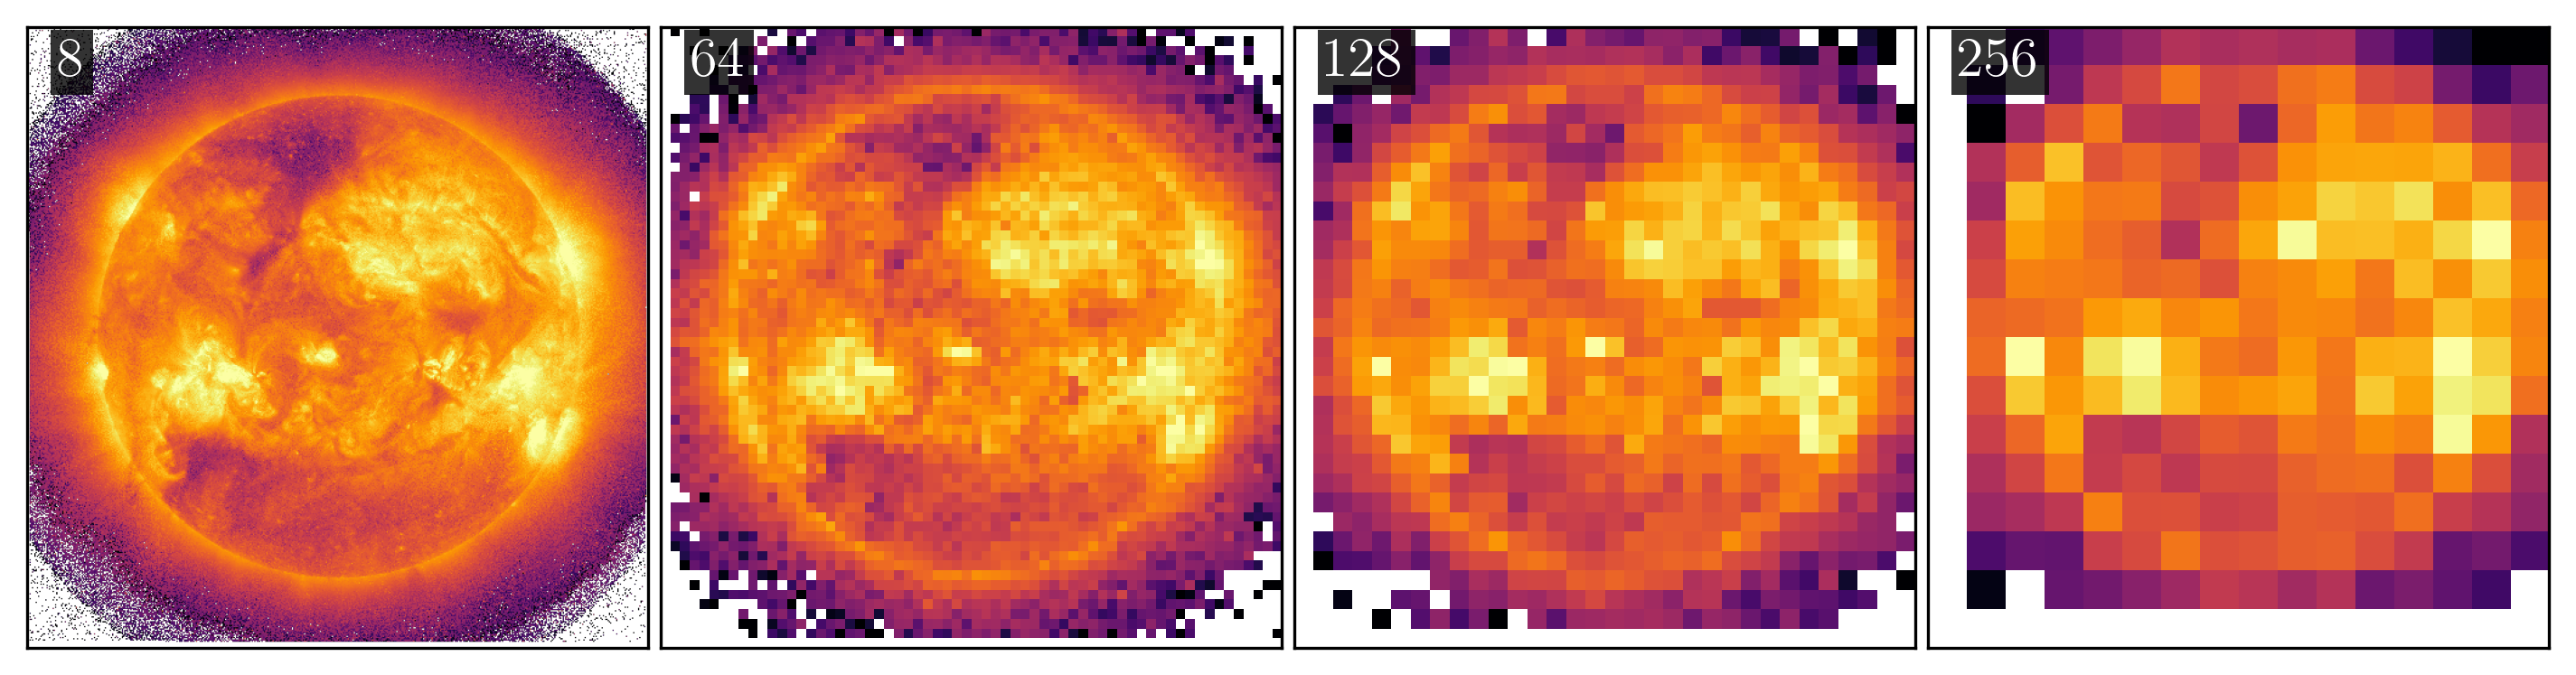

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

keys   = ['npz_8', 'npz_64', 'npz_128', 'npz']
titles = ['8', '64', '128', '256']

# Calcular todos los EM primero
EMs = []

for key in keys:
    DEM = dems[key]
    EM = DEM.sum(axis=0)
    EMs.append(EM)

# Escala común para todos los paneles
positive = np.concatenate([em[em > 0].ravel() for em in EMs])

vmin = np.percentile(positive, 1)
vmax = np.percentile(positive, 99.5)

fig, axes = plt.subplots(1, 4, figsize=(12, 4))

for ax, EM, title in zip(axes, EMs, titles):

    im = ax.imshow(
        EM,
        origin='lower',
        cmap='inferno',
        norm=LogNorm(vmin=vmin, vmax=vmax)
    )

    ax.set_xticks([])
    ax.set_yticks([])

    ax.text(
        0.05, 0.92,
        title,
        transform=ax.transAxes,
        fontsize=15,
        color='white',
        weight='bold',
        bbox=dict(
            facecolor='black',
            alpha=0.8,
            edgecolor='none',
            pad=2
        )
    )

plt.subplots_adjust(wspace=0.02)

plt.savefig(
    "decode_img.png",
    dpi=300,
    bbox_inches='tight',
    pad_inches=0.02
)

plt.show()